# 02c -- Projection test: do chromosomes influence pole movement?

## Notation

Let $\mathbf{y}_p(t) \in \mathbb{R}^3$ denote the position of pole
$p \in \{1, 2\}$ and $\mathbf{x}_j(t) \in \mathbb{R}^3$ the position
of chromosome $j \in \{1, \dots, N\}$ at frame $t$.  Define the
centers of mass:

$$
\bar{\mathbf{y}}(t) = \tfrac{1}{2}\bigl[\mathbf{y}_1(t) + \mathbf{y}_2(t)\bigr]
\qquad\text{(pole midpoint)},
\qquad
\bar{\mathbf{x}}(t) = \tfrac{1}{N}\sum_{j=1}^{N} \mathbf{x}_j(t)
\qquad\text{(chromosome COM)}.
$$

## Direction vectors

**Chrom-pole direction** (unit vector from pole midpoint toward chromosome cloud):

$$
\hat{\mathbf{u}}_\mathrm{cp}(t)
= \frac{\bar{\mathbf{x}}(t) - \bar{\mathbf{y}}(t)}
       {\|\bar{\mathbf{x}}(t) - \bar{\mathbf{y}}(t)\|}.
$$

**Pole-pole direction** (unit vector along spindle axis):

$$
\hat{\mathbf{u}}_\mathrm{pp}(t)
= \frac{\mathbf{y}_2(t) - \mathbf{y}_1(t)}
       {\|\mathbf{y}_2(t) - \mathbf{y}_1(t)\|}.
$$

Projections use unit direction vectors so that each dot product
$\mathbf{v} \cdot \hat{\mathbf{u}}$ gives the displacement component
along that direction in um/step, independent of the magnitude of the
offset.

## Forward-difference displacements

All displacements use a single-step forward difference (direction
measured at $t$, displacement over $[t, t+1]$) to preserve causality:

$$
\mathbf{v}_\mathrm{pole}(t) = \bar{\mathbf{y}}(t+1) - \bar{\mathbf{y}}(t),
\qquad
\mathbf{v}_\mathrm{chrom}(t) = \bar{\mathbf{x}}(t+1) - \bar{\mathbf{x}}(t).
$$

## Projections

For each cell and each valid frame $t$, we compute four scalar
projections:

| label | quantity | question |
|-------|---------|----------|
| `cp_pole` | $\mathbf{v}_\mathrm{pole}(t) \cdot \hat{\mathbf{u}}_\mathrm{cp}(t)$ | Does the pole midpoint move toward the chromosome cloud? |
| `cp_chrom` | $\mathbf{v}_\mathrm{chrom}(t) \cdot \hat{\mathbf{u}}_\mathrm{cp}(t)$ | Does the chromosome cloud move along the chrom-pole axis? |
| `cp_rel` | $\bigl[\mathbf{v}_\mathrm{chrom}(t) - \mathbf{v}_\mathrm{pole}(t)\bigr] \cdot \hat{\mathbf{u}}_\mathrm{cp}(t)$ | Does the chromosome cloud close on the pole midpoint along the chrom-pole axis? |
| `pp_pole` | $\mathbf{v}_\mathrm{pole}(t) \cdot \hat{\mathbf{u}}_\mathrm{pp}(t)$ | Does the pole midpoint move along the spindle axis? |
| `pp_chrom` | $\mathbf{v}_\mathrm{chrom}(t) \cdot \hat{\mathbf{u}}_\mathrm{pp}(t)$ | Does the chromosome cloud move along the spindle axis? |
| `pp_rel` | $\bigl[\mathbf{v}_\mathrm{chrom}(t) - \mathbf{v}_\mathrm{pole}(t)\bigr] \cdot \hat{\mathbf{u}}_\mathrm{pp}(t)$ | Does the chromosome cloud move relative to the poles along the spindle axis? |

**Expected results if chromosomes do not influence poles:**
`cp_rel` should be significantly negative (chromosomes close on the
pole midpoint relative to the poles, i.e. they move opposite to
$\hat{\mathbf{u}}_\mathrm{cp}$).  The lab-frame terms `cp_pole` and
`cp_chrom` can both be shifted by any common translation of the whole
spindle-plus-chromosome system.

## Note on statistics

Consecutive timepoints within a cell are autocorrelated, so a naive
t-test on pooled (cell, timepoint) samples would overstate significance.
The summary table reports per-cell means and standard errors across
the 12 cells, which is the appropriate unit of replication.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())

from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import pole_center, trim_trajectory

plt.rcParams["figure.dpi"] = 110

## Load and trim cells

In [2]:
CONDITION = "rpe18_ctr"
FRAC = 0.4
MIN_FRAMES = 25

cells_raw = load_condition(CONDITION)
cells = []
for c in cells_raw:
    try:
        cells.append(trim_trajectory(c, method="neb_ao_frac", frac=FRAC, min_frames=MIN_FRAMES))
    except ValueError as e:
        print(f"  Skipping {c.cell_id}: {e}")
print(f"Loaded {len(cells)} {CONDITION} cells")

Loaded 12 rpe18_ctr cells


## Compute projections

In [3]:
def _precompute_cell(cell):
    """Precompute direction vectors and displacements for one cell.

    Returns arrays indexed by valid timepoints (NaN-free, nonzero norms).
    All displacements are forward differences: v(t) = x(t+1) - x(t).
    """
    pole_com = pole_center(cell)                       # (T, 3)
    chrom_com = np.nanmean(cell.chromosomes, axis=2)   # (T, 3)
    p1 = cell.centrioles[:, :, 0]
    p2 = cell.centrioles[:, :, 1]
    T = pole_com.shape[0]

    # Direction vectors at each t
    u_cp = chrom_com - pole_com          # pole midpoint -> chrom cloud
    u_pp = p2 - p1                       # spindle axis

    # Forward displacements, valid for t = 0..T-2
    v_pole = pole_com[1:] - pole_com[:-1]    # (T-1, 3)
    v_chrom = chrom_com[1:] - chrom_com[:-1]  # (T-1, 3)

    # Valid mask: no NaN in displacements or positions at t
    valid = np.ones(T - 1, dtype=bool)
    valid &= ~np.any(np.isnan(v_pole), axis=1)
    valid &= ~np.any(np.isnan(v_chrom), axis=1)
    valid &= ~np.any(np.isnan(chrom_com[:T - 1]), axis=1)

    # Restrict to valid timepoints
    v_pole = v_pole[valid]      # (M, 3)
    v_chrom = v_chrom[valid]    # (M, 3)
    u_cp = u_cp[:T - 1][valid]  # (M, 3)
    u_pp = u_pp[:T - 1][valid]  # (M, 3)

    # Normalize to unit vectors
    cp_norm = np.linalg.norm(u_cp, axis=1, keepdims=True)
    pp_norm = np.linalg.norm(u_pp, axis=1, keepdims=True)
    u_cp = np.where(cp_norm > 1e-6, u_cp / cp_norm, 0.0)
    u_pp = np.where(pp_norm > 1e-6, u_pp / pp_norm, 0.0)

    v_rel = v_chrom - v_pole

    return v_pole, v_chrom, v_rel, u_cp, u_pp


def _dot_rows(a, b):
    """Row-wise dot product of two (M, 3) arrays -> (M,)."""
    return np.sum(a * b, axis=1)

In [4]:
# Precompute per-cell arrays
cell_data = [_precompute_cell(c) for c in cells]
keys = ["cp_pole", "cp_chrom", "cp_rel", "pp_pole", "pp_chrom", "pp_rel"]

# Real projections: per-cell means and pooled
cell_means = {k: [] for k in keys}
pooled = {k: [] for k in keys}

for v_pole, v_chrom, v_rel, u_cp, u_pp in cell_data:
    projs = {
        "cp_pole":  _dot_rows(v_pole, u_cp),
        "cp_chrom": _dot_rows(v_chrom, u_cp),
        "cp_rel":   _dot_rows(v_rel, u_cp),
        "pp_pole":  _dot_rows(v_pole, u_pp),
        "pp_chrom": _dot_rows(v_chrom, u_pp),
        "pp_rel":   _dot_rows(v_rel, u_pp),
    }
    for k in keys:
        pooled[k].append(projs[k])
        cell_means[k].append(projs[k].mean())

pooled = {k: np.concatenate(v) for k, v in pooled.items()}
cell_means = {k: np.array(v) for k, v in cell_means.items()}

for k in keys:
    print(f"  {k}: n_pooled={len(pooled[k])}, "
          f"cell_mean={cell_means[k].mean():.4f} +/- {cell_means[k].std():.4f}")

  cp_pole: n_pooled=1203, cell_mean=0.0133 +/- 0.0100
  cp_chrom: n_pooled=1203, cell_mean=0.0028 +/- 0.0138
  cp_rel: n_pooled=1203, cell_mean=-0.0104 +/- 0.0069
  pp_pole: n_pooled=1203, cell_mean=-0.0038 +/- 0.0087
  pp_chrom: n_pooled=1203, cell_mean=-0.0018 +/- 0.0103
  pp_rel: n_pooled=1203, cell_mean=0.0020 +/- 0.0097


## Histograms

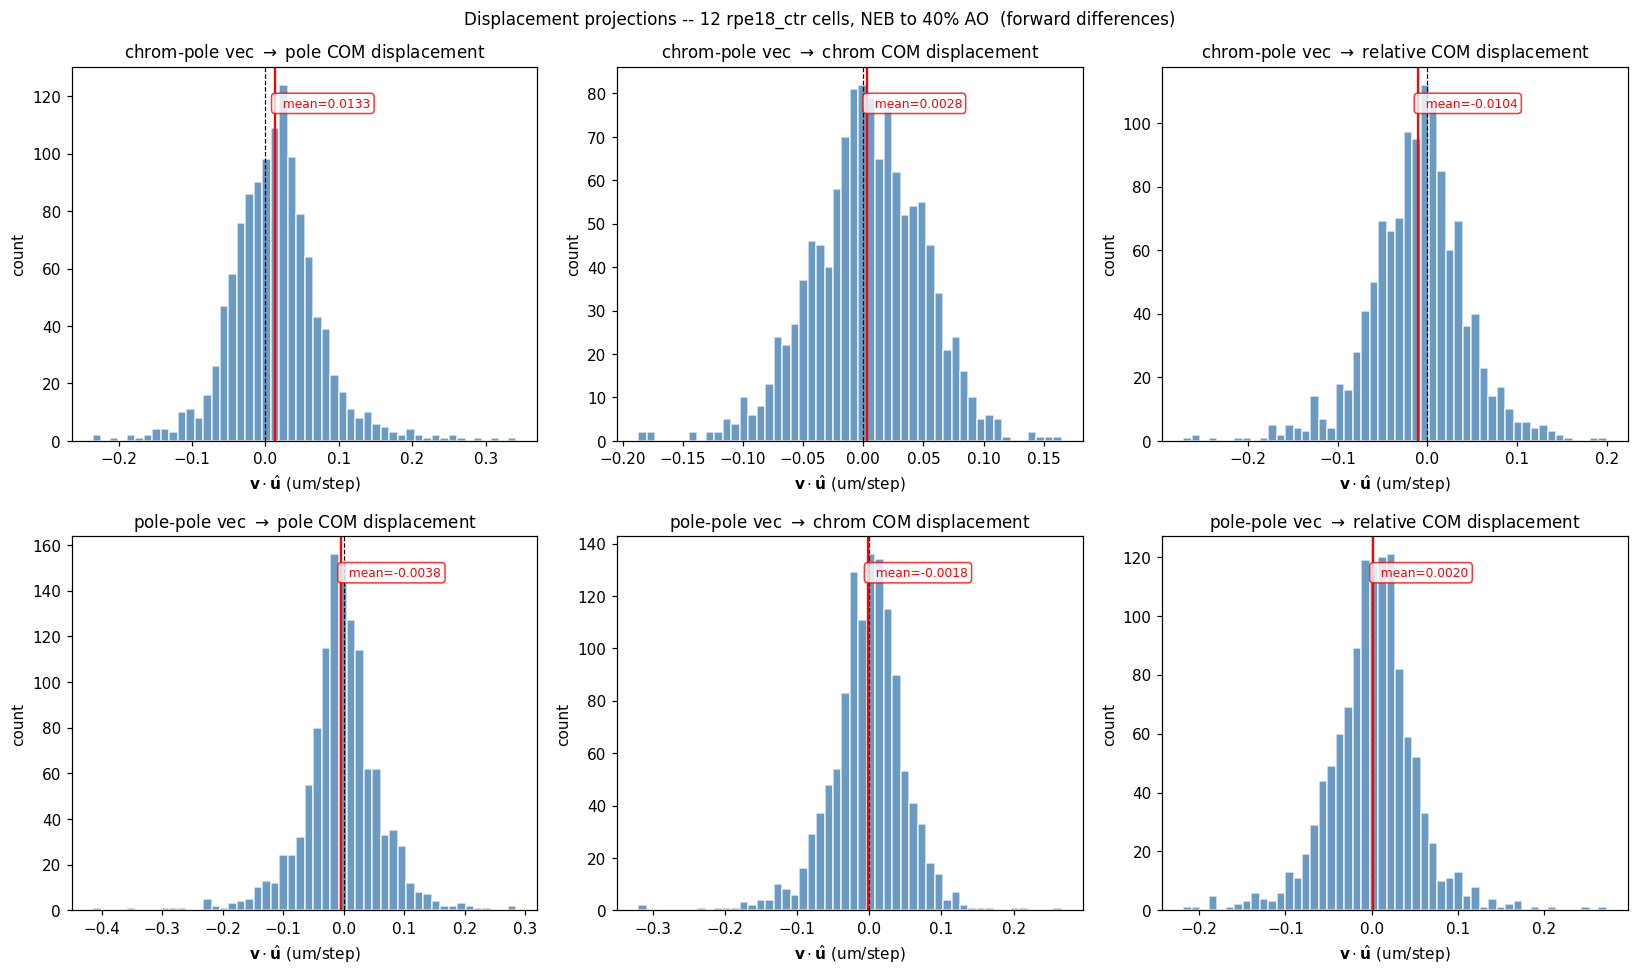

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

titles = {
    "cp_pole":  "chrom-pole vec $\\to$ pole COM displacement",
    "cp_chrom": "chrom-pole vec $\\to$ chrom COM displacement",
    "cp_rel":   "chrom-pole vec $\\to$ relative COM displacement",
    "pp_pole":  "pole-pole vec $\\to$ pole COM displacement",
    "pp_chrom": "pole-pole vec $\\to$ chrom COM displacement",
    "pp_rel":   "pole-pole vec $\\to$ relative COM displacement",
}

for ax, key in zip(axes.flat, keys):
    data = pooled[key]
    ax.hist(data, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="k", lw=0.8, ls="--")

    obs = cell_means[key].mean()
    ax.axvline(obs, color="red", lw=1.5)
    ylim = ax.get_ylim()
    ax.text(obs, ylim[1] * 0.92,
            f"  mean={obs:.4f}",
            fontsize=8, color="red", va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))

    ax.set_title(titles[key], fontsize=11)
    ax.set_xlabel(r"$\mathbf{v} \cdot \hat{\mathbf{u}}$ (um/step)")
    ax.set_ylabel("count")

fig.suptitle(
    f"Displacement projections -- {len(cells)} {CONDITION} cells, "
    f"NEB to {FRAC:.0%} AO  (forward differences)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## Summary table

In [6]:
print(f"{'projection':<15s} {'n_pts':>6s} {'n_cells':>7s} {'cell_mean':>10s} "
      f"{'cell_se':>8s}")
print("-" * 50)
for k in keys:
    cm = cell_means[k]
    print(f"{k:<15s} {len(pooled[k]):6d} {len(cm):7d} {cm.mean():10.4f} "
          f"{cm.std()/np.sqrt(len(cm)):8.4f}")

projection       n_pts n_cells  cell_mean  cell_se
--------------------------------------------------
cp_pole           1203      12     0.0133   0.0029
cp_chrom          1203      12     0.0028   0.0040
cp_rel            1203      12    -0.0104   0.0020
pp_pole           1203      12    -0.0038   0.0025
pp_chrom          1203      12    -0.0018   0.0030
pp_rel            1203      12     0.0020   0.0028


## Interpretation

- **cp_pole** (chrom-pole vec -> pole displacement): Pole midpoint motion
  along the chrom-pole axis in the lab frame.  This is informative, but
  it can reflect both pole response and common translation of the whole
  pole-plus-chromosome system.

- **cp_chrom** (chrom-pole vec -> chrom displacement): A negative mean
  indicates chromosomes move toward the pole midpoint (gathering).
  A positive mean indicates they move away from it.

- **cp_rel** (chrom-pole vec -> relative displacement): The first-order
  closing rate of chromosome COM relative to the pole midpoint.  A
  negative mean indicates chromosomes move toward the pole midpoint
  relative to the poles.

- **pp_pole** (pole-pole vec -> pole displacement): Reflects pole
  separation along the spindle axis (sanity check).

- **pp_chrom** (pole-pole vec -> chrom displacement): Shows how much
  chromosome motion is along the spindle axis.

- **pp_rel** (pole-pole vec -> relative displacement): Relative
  chromosome-versus-pole motion along the spindle axis.

## Sensitivity to smoothing

The raw trajectories contain measurement/tracking noise.  How much of
the projection signal (or lack thereof) is driven by high-frequency
noise vs genuine low-frequency motion?

We repeat the full analysis after Savitzky-Golay smoothing the raw 3D
chromosome and pole trajectories (before computing COMs), using window
lengths of 11 and 21 frames.  To make the comparison easier to read,
we overlay the raw and smoothed histograms in one figure for each
projection panel.  If the curves change substantially, noise structure
matters; if they are stable, the conclusions are robust.

In [7]:
from scipy.signal import savgol_filter


def _precompute_cell_smoothed(cell, window):
    """Same as _precompute_cell but with Savitzky-Golay smoothed trajectories.

    Smoothing is applied to each spatial coordinate of each chromosome
    and each pole independently, before computing COMs.
    """
    polyorder = min(3, window - 1)

    # Smooth pole trajectories: (T, 3, 2)
    centrioles_sm = np.empty_like(cell.centrioles)
    for p in range(2):
        for d in range(3):
            centrioles_sm[:, d, p] = savgol_filter(
                cell.centrioles[:, d, p], window, polyorder)

    # Smooth chromosome trajectories: (T, 3, N)
    chroms_sm = np.empty_like(cell.chromosomes)
    for j in range(cell.chromosomes.shape[2]):
        for d in range(3):
            col = cell.chromosomes[:, d, j]
            if np.any(np.isnan(col)):
                chroms_sm[:, d, j] = col  # leave NaN tracks unsmoothed
            else:
                chroms_sm[:, d, j] = savgol_filter(col, window, polyorder)

    # COMs from smoothed trajectories
    pole_com = 0.5 * (centrioles_sm[:, :, 0] + centrioles_sm[:, :, 1])
    chrom_com = np.nanmean(chroms_sm, axis=2)
    p1 = centrioles_sm[:, :, 0]
    p2 = centrioles_sm[:, :, 1]
    T = pole_com.shape[0]

    u_cp = chrom_com - pole_com
    u_pp = p2 - p1
    v_pole = pole_com[1:] - pole_com[:-1]
    v_chrom = chrom_com[1:] - chrom_com[:-1]

    valid = np.ones(T - 1, dtype=bool)
    valid &= ~np.any(np.isnan(v_pole), axis=1)
    valid &= ~np.any(np.isnan(v_chrom), axis=1)
    valid &= ~np.any(np.isnan(chrom_com[:T - 1]), axis=1)

    v_pole, v_chrom = v_pole[valid], v_chrom[valid]
    u_cp, u_pp = u_cp[:T - 1][valid], u_pp[:T - 1][valid]

    # Normalize to unit vectors
    cp_norm = np.linalg.norm(u_cp, axis=1, keepdims=True)
    pp_norm = np.linalg.norm(u_pp, axis=1, keepdims=True)
    u_cp = np.where(cp_norm > 1e-6, u_cp / cp_norm, 0.0)
    u_pp = np.where(pp_norm > 1e-6, u_pp / pp_norm, 0.0)

    v_rel = v_chrom - v_pole

    return v_pole, v_chrom, v_rel, u_cp, u_pp

In [8]:
WINDOWS = [11, 21]

smooth_results = {
    "raw": {"pooled": pooled, "cell_means": cell_means},
}

for win in WINDOWS:
    print(f"\n=== Savitzky-Golay smoothing, window={win} frames ===")
    cell_data_sm = [_precompute_cell_smoothed(c, win) for c in cells]

    cm_sm = {k: [] for k in keys}
    pooled_sm = {k: [] for k in keys}
    for vp, vc, vr, ucp, upp in cell_data_sm:
        projs_sm = {
            "cp_pole":  _dot_rows(vp, ucp),
            "cp_chrom": _dot_rows(vc, ucp),
            "cp_rel":   _dot_rows(vr, ucp),
            "pp_pole":  _dot_rows(vp, upp),
            "pp_chrom": _dot_rows(vc, upp),
            "pp_rel":   _dot_rows(vr, upp),
        }
        for k in keys:
            pooled_sm[k].append(projs_sm[k])
            cm_sm[k].append(projs_sm[k].mean())
    pooled_sm = {k: np.concatenate(v) for k, v in pooled_sm.items()}
    cm_sm = {k: np.array(v) for k, v in cm_sm.items()}
    smooth_results[f"w{win}"] = {"pooled": pooled_sm, "cell_means": cm_sm}

    print(f"{'projection':<15s} {'cell_mean':>10s} {'cell_std':>10s}")
    print("-" * 40)
    for k in keys:
        arr = np.array(cm_sm[k])
        print(f"{k:<15s} {arr.mean():10.4f} {arr.std():10.4f}")


=== Savitzky-Golay smoothing, window=11 frames ===


projection       cell_mean   cell_std
----------------------------------------
cp_pole             0.0111     0.0104
cp_chrom            0.0033     0.0137
cp_rel             -0.0078     0.0060
pp_pole            -0.0040     0.0089
pp_chrom           -0.0020     0.0105
pp_rel              0.0020     0.0095

=== Savitzky-Golay smoothing, window=21 frames ===


projection       cell_mean   cell_std
----------------------------------------
cp_pole             0.0106     0.0103
cp_chrom            0.0032     0.0137
cp_rel             -0.0074     0.0060
pp_pole            -0.0042     0.0085
pp_chrom           -0.0021     0.0105
pp_rel              0.0021     0.0094


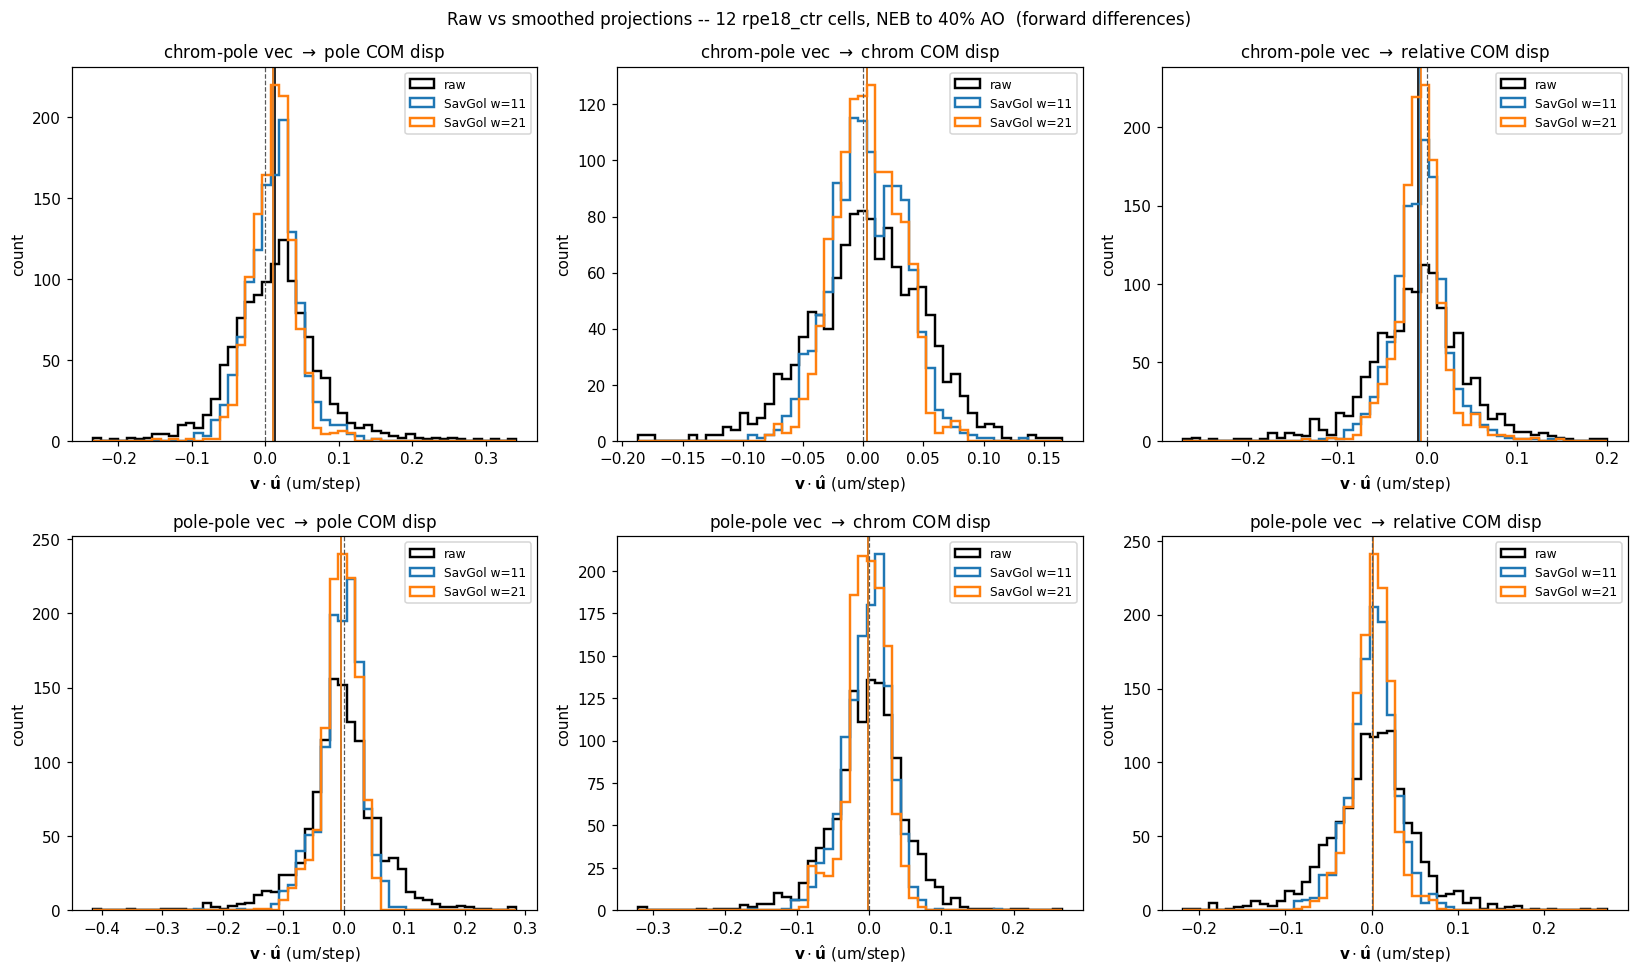

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
titles_sm = {
    "cp_pole":  "chrom-pole vec $\\to$ pole COM disp",
    "cp_chrom": "chrom-pole vec $\\to$ chrom COM disp",
    "cp_rel":   "chrom-pole vec $\\to$ relative COM disp",
    "pp_pole":  "pole-pole vec $\\to$ pole COM disp",
    "pp_chrom": "pole-pole vec $\\to$ chrom COM disp",
    "pp_rel":   "pole-pole vec $\\to$ relative COM disp",
}
styles = {
    "raw": {"color": "k", "label": "raw"},
    "w11": {"color": "C0", "label": "SavGol w=11"},
    "w21": {"color": "C1", "label": "SavGol w=21"},
}

for ax, key in zip(axes.flat, keys):
    combined = np.concatenate([smooth_results[name]["pooled"][key] for name in styles])
    bins = np.histogram_bin_edges(combined, bins=50)

    for name, style in styles.items():
        data = smooth_results[name]["pooled"][key]
        ax.hist(
            data,
            bins=bins,
            histtype="step",
            linewidth=1.6,
            color=style["color"],
            label=style["label"],
        )
        obs = smooth_results[name]["cell_means"][key].mean()
        ax.axvline(obs, color=style["color"], lw=1.2, alpha=0.9)

    ax.axvline(0, color="0.35", lw=0.8, ls="--")
    ax.set_title(titles_sm[key], fontsize=11)
    ax.set_xlabel(r"$\mathbf{v} \cdot \hat{\mathbf{u}}$ (um/step)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

fig.suptitle(
    f"Raw vs smoothed projections -- {len(cells)} {CONDITION} cells, "
    f"NEB to {FRAC:.0%} AO  (forward differences)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## PRC1 depletion comparison

Repeat the same projections on `rpe18_prc` cells.  Alex's original
MATLAB analysis used PRC1-depleted data; comparing both conditions
side-by-side clarifies whether the qualitative pattern (which
projection is nonzero) differs between control and PRC1 depletion.

In [10]:
CONDITION_PRC = "rpe18_prc"

cells_prc_raw = load_condition(CONDITION_PRC)
cells_prc = []
for c in cells_prc_raw:
    try:
        cells_prc.append(trim_trajectory(c, method="neb_ao_frac", frac=FRAC, min_frames=MIN_FRAMES))
    except ValueError as e:
        print(f"  Skipping {c.cell_id}: {e}")
print(f"Loaded {len(cells_prc)} {CONDITION_PRC} cells")

Loaded 14 rpe18_prc cells


In [11]:
cell_data_prc = [_precompute_cell(c) for c in cells_prc]

cell_means_prc = {k: [] for k in keys}
pooled_prc = {k: [] for k in keys}

for v_pole, v_chrom, v_rel, u_cp, u_pp in cell_data_prc:
    projs = {
        "cp_pole":  _dot_rows(v_pole, u_cp),
        "cp_chrom": _dot_rows(v_chrom, u_cp),
        "cp_rel":   _dot_rows(v_rel, u_cp),
        "pp_pole":  _dot_rows(v_pole, u_pp),
        "pp_chrom": _dot_rows(v_chrom, u_pp),
        "pp_rel":   _dot_rows(v_rel, u_pp),
    }
    for k in keys:
        pooled_prc[k].append(projs[k])
        cell_means_prc[k].append(projs[k].mean())

pooled_prc = {k: np.concatenate(v) for k, v in pooled_prc.items()}
cell_means_prc = {k: np.array(v) for k, v in cell_means_prc.items()}

C:\Users\Chris\AppData\Local\Temp\ipykernel_33032\4154828764.py:8: RuntimeWarning: Mean of empty slice
  chrom_com = np.nanmean(cell.chromosomes, axis=2)   # (T, 3)


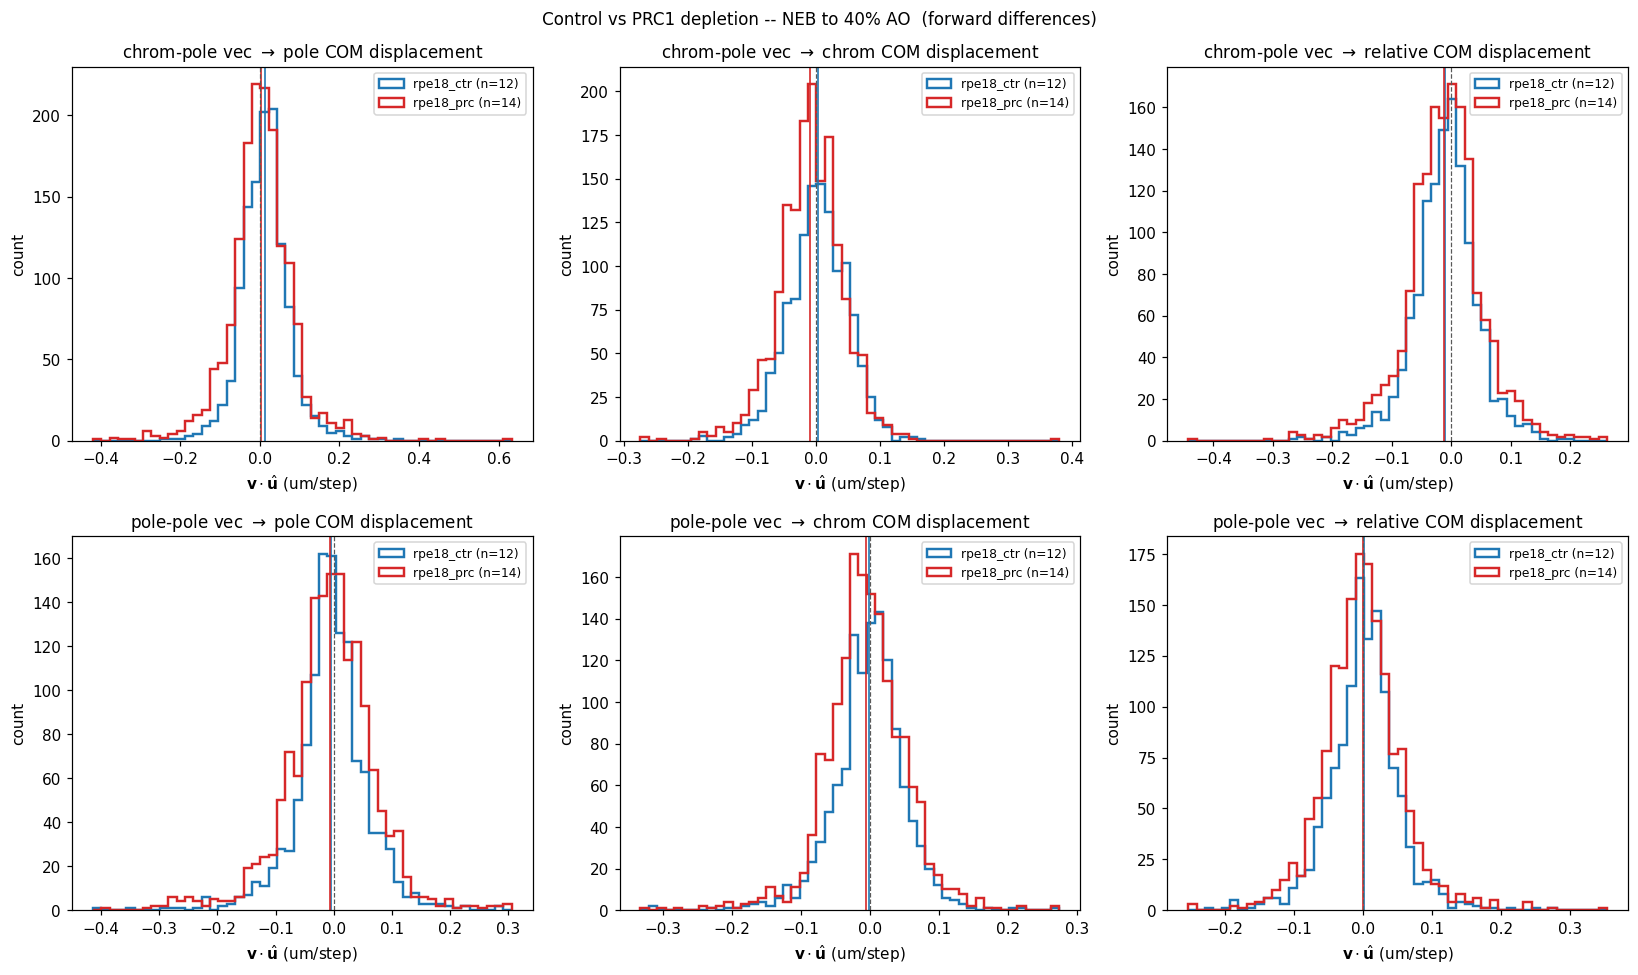

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, key in zip(axes.flat, keys):
    combined = np.concatenate([pooled[key], pooled_prc[key]])
    bins = np.histogram_bin_edges(combined, bins=50)

    ax.hist(pooled[key], bins=bins, histtype="step", linewidth=1.6,
            color="C0", label=f"{CONDITION} (n={len(cells)})")
    ax.hist(pooled_prc[key], bins=bins, histtype="step", linewidth=1.6,
            color="C3", label=f"{CONDITION_PRC} (n={len(cells_prc)})")

    obs_ctr = cell_means[key].mean()
    obs_prc = cell_means_prc[key].mean()
    ax.axvline(obs_ctr, color="C0", lw=1.2, alpha=0.9)
    ax.axvline(obs_prc, color="C3", lw=1.2, alpha=0.9)
    ax.axvline(0, color="0.35", lw=0.8, ls="--")

    ax.set_title(titles[key], fontsize=11)
    ax.set_xlabel(r"$\mathbf{v} \cdot \hat{\mathbf{u}}$ (um/step)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

fig.suptitle(
    f"Control vs PRC1 depletion -- NEB to {FRAC:.0%} AO  (forward differences)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

In [13]:
print(f"{'projection':<15s} {'condition':>12s} {'n_pts':>6s} {'n_cells':>7s} "
      f"{'cell_mean':>10s} {'cell_se':>8s}")
print("-" * 65)
for k in keys:
    cm = cell_means[k]
    print(f"{k:<15s} {CONDITION:>12s} {len(pooled[k]):6d} {len(cm):7d} "
          f"{cm.mean():10.4f} {cm.std()/np.sqrt(len(cm)):8.4f}")
    cm_p = cell_means_prc[k]
    print(f"{'':<15s} {CONDITION_PRC:>12s} {len(pooled_prc[k]):6d} {len(cm_p):7d} "
          f"{cm_p.mean():10.4f} {cm_p.std()/np.sqrt(len(cm_p)):8.4f}")

projection         condition  n_pts n_cells  cell_mean  cell_se
-----------------------------------------------------------------
cp_pole            rpe18_ctr   1203      12     0.0133   0.0029
                   rpe18_prc   1574      14     0.0031   0.0034
cp_chrom           rpe18_ctr   1203      12     0.0028   0.0040
                   rpe18_prc   1574      14    -0.0087   0.0031
cp_rel             rpe18_ctr   1203      12    -0.0104   0.0020
                   rpe18_prc   1574      14    -0.0118   0.0024
pp_pole            rpe18_ctr   1203      12    -0.0038   0.0025
                   rpe18_prc   1574      14    -0.0070   0.0047
pp_chrom           rpe18_ctr   1203      12    -0.0018   0.0030
                   rpe18_prc   1574      14    -0.0067   0.0040
pp_rel             rpe18_ctr   1203      12     0.0020   0.0028
                   rpe18_prc   1574      14     0.0003   0.0038


## 2D vs 3D sensitivity

Alex's MATLAB code uses only (x, y).  Check whether restricting to 2D
changes the qualitative results for the control cells.

In [14]:
def _precompute_cell_2d(cell):
    """Same as _precompute_cell but restricted to x,y (columns 0,1)."""
    pole_com = pole_center(cell)[:, :2]
    chrom_com = np.nanmean(cell.chromosomes, axis=2)[:, :2]
    p1 = cell.centrioles[:, :2, 0]
    p2 = cell.centrioles[:, :2, 1]
    T = pole_com.shape[0]

    u_cp = chrom_com - pole_com
    u_pp = p2 - p1
    v_pole = pole_com[1:] - pole_com[:-1]
    v_chrom = chrom_com[1:] - chrom_com[:-1]

    valid = np.ones(T - 1, dtype=bool)
    valid &= ~np.any(np.isnan(v_pole), axis=1)
    valid &= ~np.any(np.isnan(v_chrom), axis=1)
    valid &= ~np.any(np.isnan(chrom_com[:T - 1]), axis=1)

    v_pole, v_chrom = v_pole[valid], v_chrom[valid]
    u_cp, u_pp = u_cp[:T - 1][valid], u_pp[:T - 1][valid]

    cp_norm = np.linalg.norm(u_cp, axis=1, keepdims=True)
    pp_norm = np.linalg.norm(u_pp, axis=1, keepdims=True)
    u_cp = np.where(cp_norm > 1e-6, u_cp / cp_norm, 0.0)
    u_pp = np.where(pp_norm > 1e-6, u_pp / pp_norm, 0.0)

    v_rel = v_chrom - v_pole
    return v_pole, v_chrom, v_rel, u_cp, u_pp

In [15]:
cell_data_2d = [_precompute_cell_2d(c) for c in cells]

cell_means_2d = {k: [] for k in keys}
pooled_2d = {k: [] for k in keys}

for v_pole, v_chrom, v_rel, u_cp, u_pp in cell_data_2d:
    projs = {
        "cp_pole":  _dot_rows(v_pole, u_cp),
        "cp_chrom": _dot_rows(v_chrom, u_cp),
        "cp_rel":   _dot_rows(v_rel, u_cp),
        "pp_pole":  _dot_rows(v_pole, u_pp),
        "pp_chrom": _dot_rows(v_chrom, u_pp),
        "pp_rel":   _dot_rows(v_rel, u_pp),
    }
    for k in keys:
        pooled_2d[k].append(projs[k])
        cell_means_2d[k].append(projs[k].mean())

pooled_2d = {k: np.concatenate(v) for k, v in pooled_2d.items()}
cell_means_2d = {k: np.array(v) for k, v in cell_means_2d.items()}

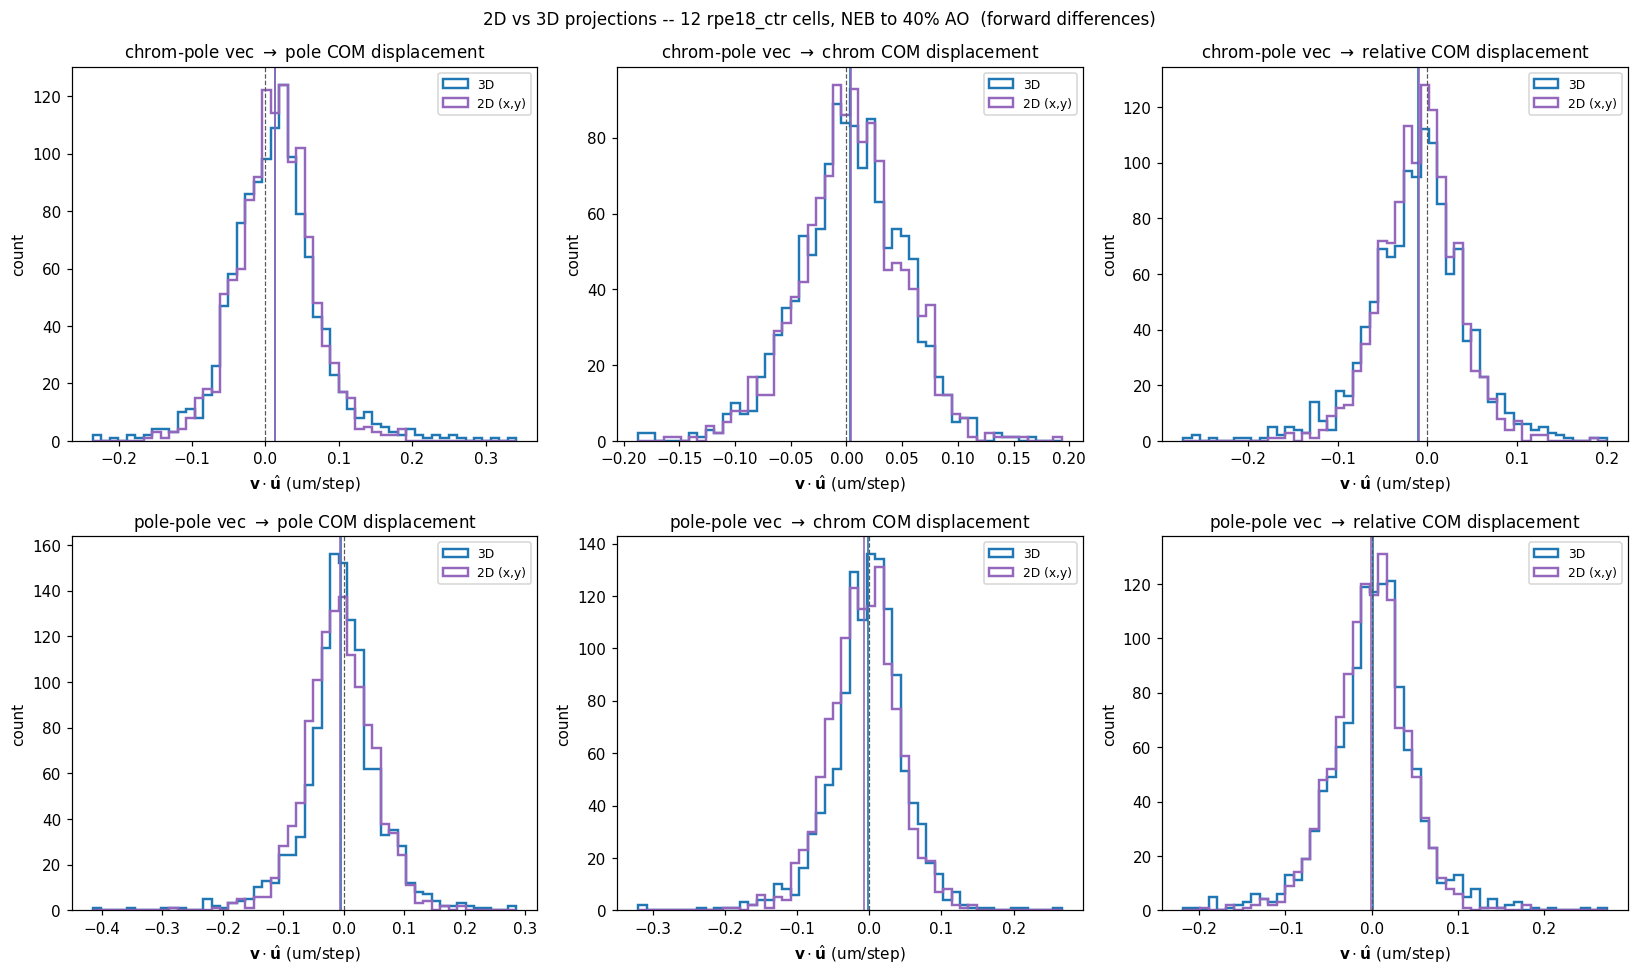

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, key in zip(axes.flat, keys):
    combined = np.concatenate([pooled[key], pooled_2d[key]])
    bins = np.histogram_bin_edges(combined, bins=50)

    ax.hist(pooled[key], bins=bins, histtype="step", linewidth=1.6,
            color="C0", label="3D")
    ax.hist(pooled_2d[key], bins=bins, histtype="step", linewidth=1.6,
            color="C4", label="2D (x,y)")

    obs_3d = cell_means[key].mean()
    obs_2d = cell_means_2d[key].mean()
    ax.axvline(obs_3d, color="C0", lw=1.2, alpha=0.9)
    ax.axvline(obs_2d, color="C4", lw=1.2, alpha=0.9)
    ax.axvline(0, color="0.35", lw=0.8, ls="--")

    ax.set_title(titles[key], fontsize=11)
    ax.set_xlabel(r"$\mathbf{v} \cdot \hat{\mathbf{u}}$ (um/step)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

fig.suptitle(
    f"2D vs 3D projections -- {len(cells)} {CONDITION} cells, "
    f"NEB to {FRAC:.0%} AO  (forward differences)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

In [17]:
print(f"{'projection':<15s} {'dim':>5s} {'n_pts':>6s} {'n_cells':>7s} "
      f"{'cell_mean':>10s} {'cell_se':>8s}")
print("-" * 55)
for k in keys:
    cm3 = cell_means[k]
    print(f"{k:<15s} {'3D':>5s} {len(pooled[k]):6d} {len(cm3):7d} "
          f"{cm3.mean():10.4f} {cm3.std()/np.sqrt(len(cm3)):8.4f}")
    cm2 = cell_means_2d[k]
    print(f"{'':<15s} {'2D':>5s} {len(pooled_2d[k]):6d} {len(cm2):7d} "
          f"{cm2.mean():10.4f} {cm2.std()/np.sqrt(len(cm2)):8.4f}")

projection        dim  n_pts n_cells  cell_mean  cell_se
-------------------------------------------------------
cp_pole            3D   1203      12     0.0133   0.0029
                   2D   1203      12     0.0133   0.0032
cp_chrom           3D   1203      12     0.0028   0.0040
                   2D   1203      12     0.0041   0.0038
cp_rel             3D   1203      12    -0.0104   0.0020
                   2D   1203      12    -0.0092   0.0017
pp_pole            3D   1203      12    -0.0038   0.0025
                   2D   1203      12    -0.0068   0.0040
pp_chrom           3D   1203      12    -0.0018   0.0030
                   2D   1203      12    -0.0072   0.0040
pp_rel             3D   1203      12     0.0020   0.0028
                   2D   1203      12    -0.0004   0.0028
